# Regressione
Proseguendo il percorso di questo progetto, l'obiettivo di questo notebook è allenare un modello capace di compiere previsioni sul valore delle concentrazioni di vari inquinanti nell'aria su base oraria e giornaliera. Tuttavia, al contrario di quanto avvenuto per la classificazione, vogliamo estrarre predizioni quantitative e non qualitative. 

In questo notebook proviamo a raggiungere questo obiettivo tramite un modello di regressione lineare.

Si seguono le considerazioni sulle time series sviluppate nei notebook precedenti.

In [1]:
# importiamo i pacchetti necessari
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression, ElasticNet

%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../..')

import src.regr_funcs as fs

In [2]:
# scelta del seed random per la riproducibilità dei risultati
seed = 58327419

Non potendo visualizzare i nostri dati nello spazio delle coppie (X, y), non possiamo a priori sapere quale sarà la funzione che meglio descriverà i nostri dati. Per tale motivo scegliamo innanzitutto di provare a fittare un modello lineare e vedere come questo si comporta. Successivamente proveremo ad allenare modelli più complessi e confronteremo i risultati.

## Regressione
In classe e nel corso delle esercitazioni abbiamo visto la teoria della regressione. Qui utilizziamo due principali regressori implementati da Sickit Learn:
* LinearRegression: modello particolarmente semplice e senza regolarizzazione, che implementa semplicemente i minimi quadrati;
* ElasticNet: modello che implementa una regressione lineare con regolarizzazione mista tra Ridge e Lasso. Ottimizziamo Elasticnet tramite cross-validation sulla time series

Costruiamo tre dataframe per la regressione, uno per ciascun inquinante da prevedere, in modo da massimizzare il numero di punti a nostra disposizione.

## Studio orario
Partiamo con uno studio su base oraria degli inquinanti.

### PM10
#### Importiamo il dataframe

In [3]:
# Importiamo il dataframe costruito separatamente
hour_PM10_df = pd.read_csv('../../data/processed/dataset_hour_PM10_processed.csv')

# droppiamo la feature Riva del Garda, che tanto non ha dati associati
hour_PM10_df.drop(columns='station_Riva del Garda', inplace=True)

hour_PM10_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,sin_week_day,...,precipitation,PM10_1,PM10_2,PM10_3,PM10_diff_1,PM10_diff_2,NO2_1,power_area_50_1,power_area_50_2,target
0,1,0,0,0,0,0,410,1,-0.900969,-0.433884,...,0.0,21.0,20.0,19.0,1.0,2.0,18.0,16.969367,14.669913,19.0
1,1,0,0,0,0,0,410,1,-0.900969,-0.433884,...,0.0,19.0,21.0,20.0,-2.0,-1.0,16.0,15.329278,16.969367,24.0
2,1,0,0,0,0,0,410,1,-0.900969,-0.433884,...,0.0,24.0,19.0,21.0,5.0,3.0,16.0,17.519438,15.329278,19.0
3,1,0,0,0,0,0,410,1,-0.900969,-0.433884,...,0.0,19.0,24.0,19.0,-5.0,0.0,15.0,17.446178,17.519438,22.0
4,1,0,0,0,0,0,410,1,-0.900969,-0.433884,...,0.0,22.0,19.0,24.0,3.0,-2.0,15.0,17.484408,17.446178,26.0


#### LinearRegression

#### Pipeline

In [4]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in hour_PM10_df.columns if col.startswith('station_')]
num_features = hour_PM10_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_reg = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('one-hot', 'passthrough', non_num_features)
])

# cross validation per time series
tscv = TimeSeriesSplit(n_splits=5)

# pipeline
model_reg = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('regressor', LinearRegression(n_jobs = -1))
])

#### Divisione in Train, Test + fit al modello
Visto che non abbiamo iperparametri da validare non introduciamo valisd

In [5]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
hPM10_X_train, _, hPM10_X_test, hPM10_y_train, _, hPM10_y_test = fs.get_train_valid_test(hour_PM10_df, 0.8, 0.0, feature_cols)

In [6]:
model_reg.fit(hPM10_X_train, hPM10_y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('one-hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

#### Quali sono le features più importanti?

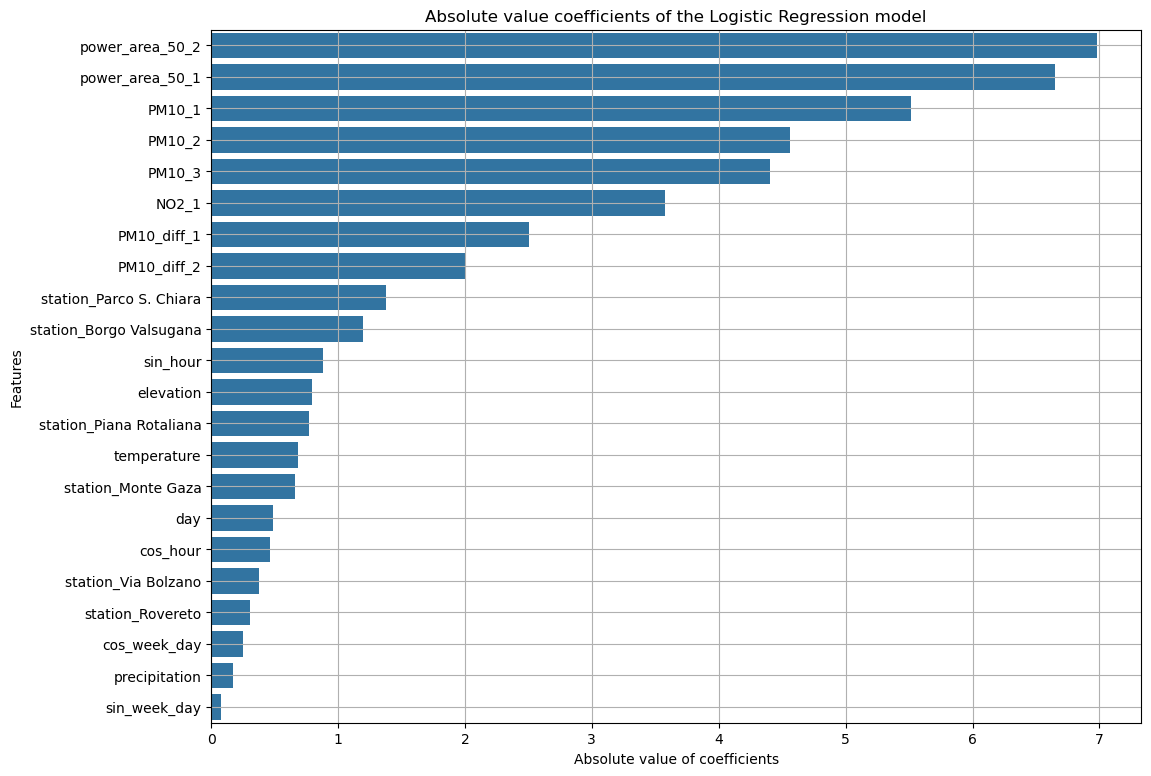

In [7]:
fs.display_abs_coefs(model_reg.named_steps['regressor'], feature_cols)

Non avendo regolarizzatori, più o meno tutte le feature risultano rilevanti. Al contrario di quanto ci si potrebbe aspettare, i dati sui consumi elettrici sono le features più importanti, mentre le rilevazioni sui PM10 e sugli altri inquinanti arrivano solo in un secondo momento. Questo risultato ci insospettisce leggermente. Proviamo ad approfondire la performance del modello in modo da capire se il nostro modello stia effettivamente funzionando correttamente.

#### Performance del modello
Cominciamo studiando quanto bene il modello fitti i dati del train

In [8]:
print('Performance su train')
fs.evaluation(model_reg, hPM10_X_train, hPM10_y_train)
print('------------------------------------------------')
print('Performance su test')
fs.evaluation(model_reg, hPM10_X_test, hPM10_y_test)

Performance su train
Mean Squared Error (MSE):          43.00751555572841
Root Mean Squared Error (RMSE):    6.5580115550163836
Mean Absolute Error (MAE):         3.5894479465962106
Coefficient of Determination (R2): 0.8795446086798205
------------------------------------------------
Performance su test
Mean Squared Error (MSE):          25.67605443145894
Root Mean Squared Error (RMSE):    5.067154470850375
Mean Absolute Error (MAE):         3.554799790335707
Coefficient of Determination (R2): 0.9533490735044674


I nostri punti sembrano seguire bene il modello lineare, con un R^2 appena sotto lo 0.9 per il train ed addirittura 0.95 per il test.
Il valore di $R^2$ superiore a 0.9 è solitamente indice di buone previsioni; tuttavia, poiché trattiamo dati con una importante dipendenza temporale, questo parametro (che fa riferimento alla media del campione) è meno rilevante. Scegliamo quindi di concentrarci maggiormente su RMSE e MAE, anche questo relativamente piccolo in confronto alle scale in gioco.

È importante ricordare di come il modello di per sé stia prevedendo l'ora successiva avendo molte informazioni sulle ore precedenti, per cui non è strano pensare che riesca a fare una buona regressione al prim'ordine dei punti del dataset. 
Seppure il fatto che i consumi elettrici siano così importanti sia una stranezza, è innegabile che il modello stia seguendo particolarmente bene l'andamento delle osservazioni sia nel train che nel test.

Proviamo a rappresentare il modello sovrapposto ai punti del dataset per capire effettivamente quanto bene stia performando il modello.

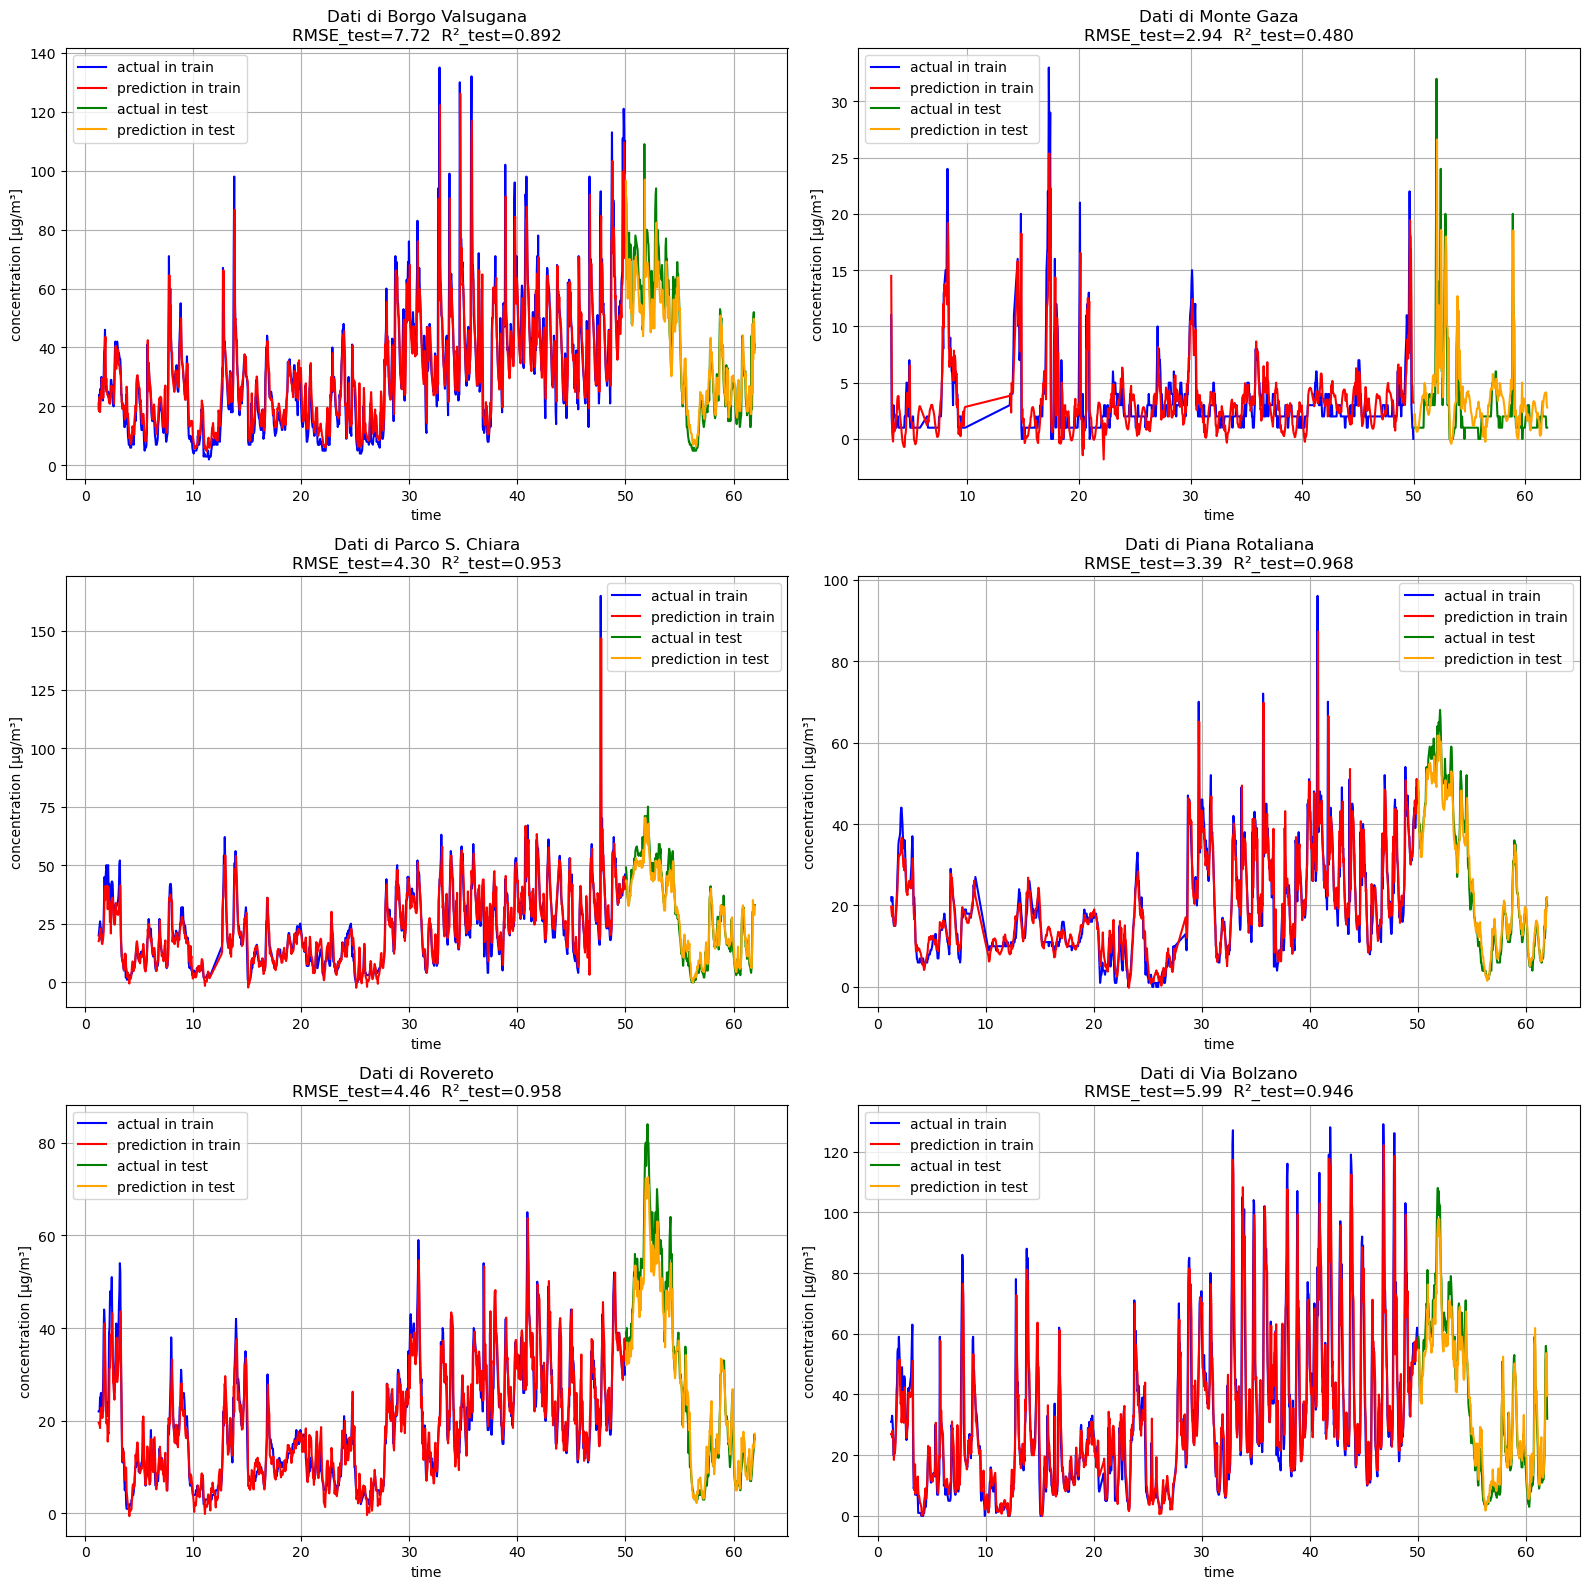

In [9]:
# proviamo a studiare graficamente la performance del regressore, creando dei grafici con il valore di PM10 sulle ordinate ed il tempo sulle ascisse
fs.plot_predictions(model_reg, hPM10_X_train, hPM10_y_train, hPM10_X_test, hPM10_y_test)

Il modello di regressione sembra fittare molto bene i nostri dati per tutte le stazioni. La stazione che sembra essere descritta peggio è quella di Monte Gaza, ma osservando bene le rilevazioni di questa stazione si nota che i dati sono particolarmente strani, con grandi sezioni in cui il valore dell'inquinante rimane stabile. È quindi possibile (e sembra essere il fenomeno che osserviamo) che il regressore, abituato alla variabilità delle altre stazioni non riesca a seguire bene l'andamento piatto dei dati del Monte Gaza.

Proviamo ad ottenere risultati migliori utilizzando il modello ElasticNet, che aggiunge una regolarizzazione al semplice modello lineare visto fino ad ora.

#### ElasticNet
#### Pipeline

In [10]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in hour_PM10_df.columns if col.startswith('station_')]
num_features = hour_PM10_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('one-hot', 'passthrough', non_num_features)
])

# cross validation per time series
tscv = TimeSeriesSplit(n_splits=5)

# pipeline
model_en = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(random_state=seed, max_iter=20000, tol=1e-3))
]) # imponiamo un limite minimo di differenza sullo step di ottimizzazione

# griglia degli iperparametri
param_grid_en = {
    'regressor__alpha': np.logspace(-2, 2, 50),                     # valori di alpha per il regolarizzatore
    'regressor__l1_ratio': [0.001, 0.1, 0.25, 0.5, 0.75, 1.0],      # rateo l1/l2 -> NB mettiamo 0.001 invece che 0.0, perché con 0.0 dà problemi di convergenza
    'regressor__fit_intercept': [True, False],                      # sceglie se mettere l'intercetta o no
    'regressor__selection': ['cyclic', 'random'],                   # sceglie il modo in cui aggiornare le features
}

# ricerca degli iperparametri
gridsrc_en = GridSearchCV(estimator=model_en,                                       # usiamo la pipeline
                         param_grid=param_grid_en,                                  # cerchiamo gli iperparametri migliori
                         scoring='neg_root_mean_squared_error',                     # metro di ottimizzazione
                         cv=tscv,                                                   # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                         n_jobs=-1,                                                 # usiamo la massima potenza disponibile nella CPU
                         refit=True)                                                # vogliamo poi allenare il modello con i migliori iperparametri

#### Train, Test split + fit
Dividiamo i dati in un insieme di training (80%) e uno di test (20%).

In [11]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
hPM10_X_train, _, hPM10_X_test, hPM10_y_train, _, hPM10_y_test = fs.get_train_valid_test(hour_PM10_df, 0.8, 0.0, feature_cols)

In [12]:
# training
gridsrc_en.fit(hPM10_X_train, hPM10_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__alpha': array([1.0000...00000000e+02]), 'regressor__fit_intercept': [True, False], 'regressor__l1_ratio': [0.001, 0.1, ...], 'regressor__selection': ['cyclic', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose

In [13]:
best_model = gridsrc_en.best_estimator_
print(gridsrc_en.best_params_)

{'regressor__alpha': np.float64(0.6250551925273969), 'regressor__fit_intercept': True, 'regressor__l1_ratio': 1.0, 'regressor__selection': 'random'}


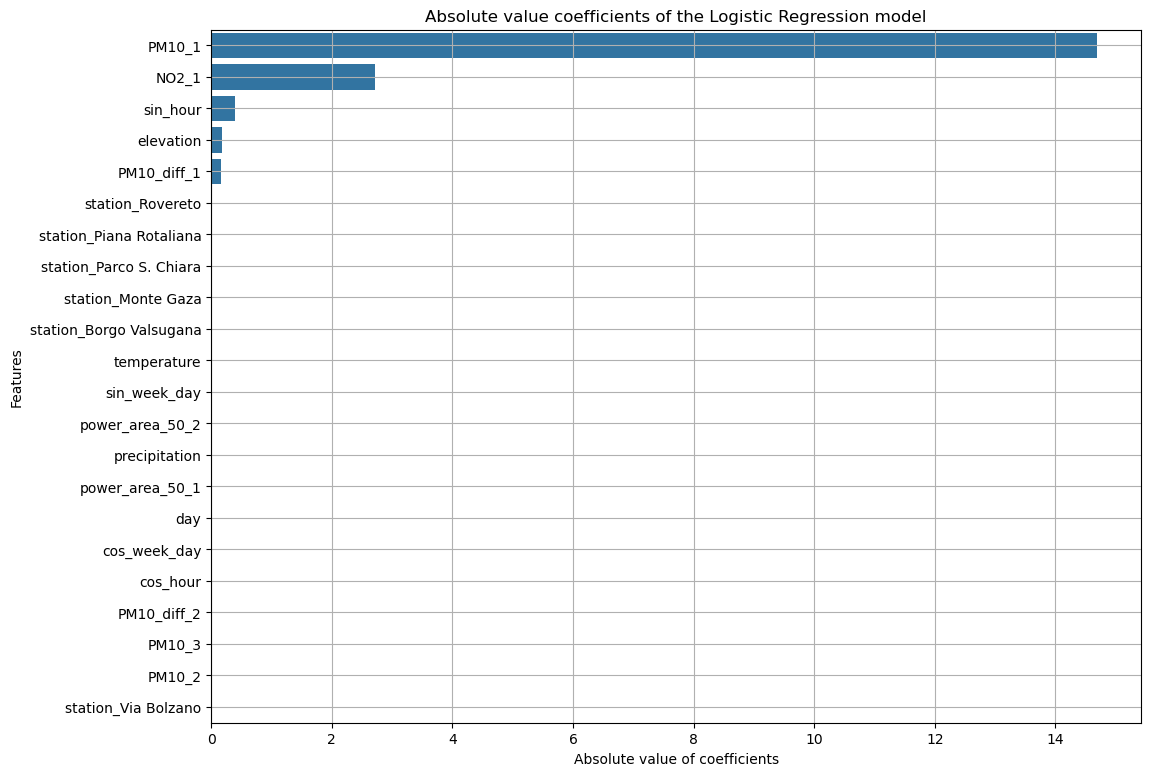

Performance su train
Mean Squared Error (MSE):          46.249967198696346
Root Mean Squared Error (RMSE):    6.800732842767487
Mean Absolute Error (MAE):         3.651651097966492
Coefficient of Determination (R2): 0.8704631545096915
------------------------------------------------
Performance su test
Mean Squared Error (MSE):          29.31638999791076
Root Mean Squared Error (RMSE):    5.414461191837168
Mean Absolute Error (MAE):         3.666480681421388
Coefficient of Determination (R2): 0.9467349331822869


In [14]:
fs.display_abs_coefs(best_model.named_steps['regressor'], feature_cols)

print('Performance su train')
fs.evaluation(best_model, hPM10_X_train, hPM10_y_train)
print('------------------------------------------------')
print('Performance su test')
fs.evaluation(best_model, hPM10_X_test, hPM10_y_test)

Come si vede dai parametri e dal grafico sui coefficienti, di fatto il gridsearch con l'ElasticNet converge ad un modello con regolarizzatore Lasso ('regressor__l1_ratio': 1.0). Questo si vede anche nei pesi sulle features, in cui la maggior parte delle features vengono mandate a zero.

In questo caso, a differenza della semplice regressione lineare, sembra che gli inquinanti siano ritornati la feature di massima importanza, mentre i consumi elettrici sono addirittura sopressi dal regressore.

Guardando i parametri notiamo un peggioramento rispetto al semplice modello lineare, il che è strano. Probabilmente l'inserimento di un regolarizzatore fa cadere l'algoritmo in un minimo locale, che non riesce a cogliere perfettamente l'andamento dei 'PM10' nel tempo.\
Provando ad abbassare la costante di regolarizzazione per riavvicinarci alla semplice regressione lineare il modello mostra problemi di convergenza. Per tale motivo, negli studi successivi ci limiteremo ad usare la regressione lineare.

Solo per questo primo inquinante rappresentiamo anche le previsioni dell'elasticnet in modo da capire dove stia la differenza tra i due modelli.

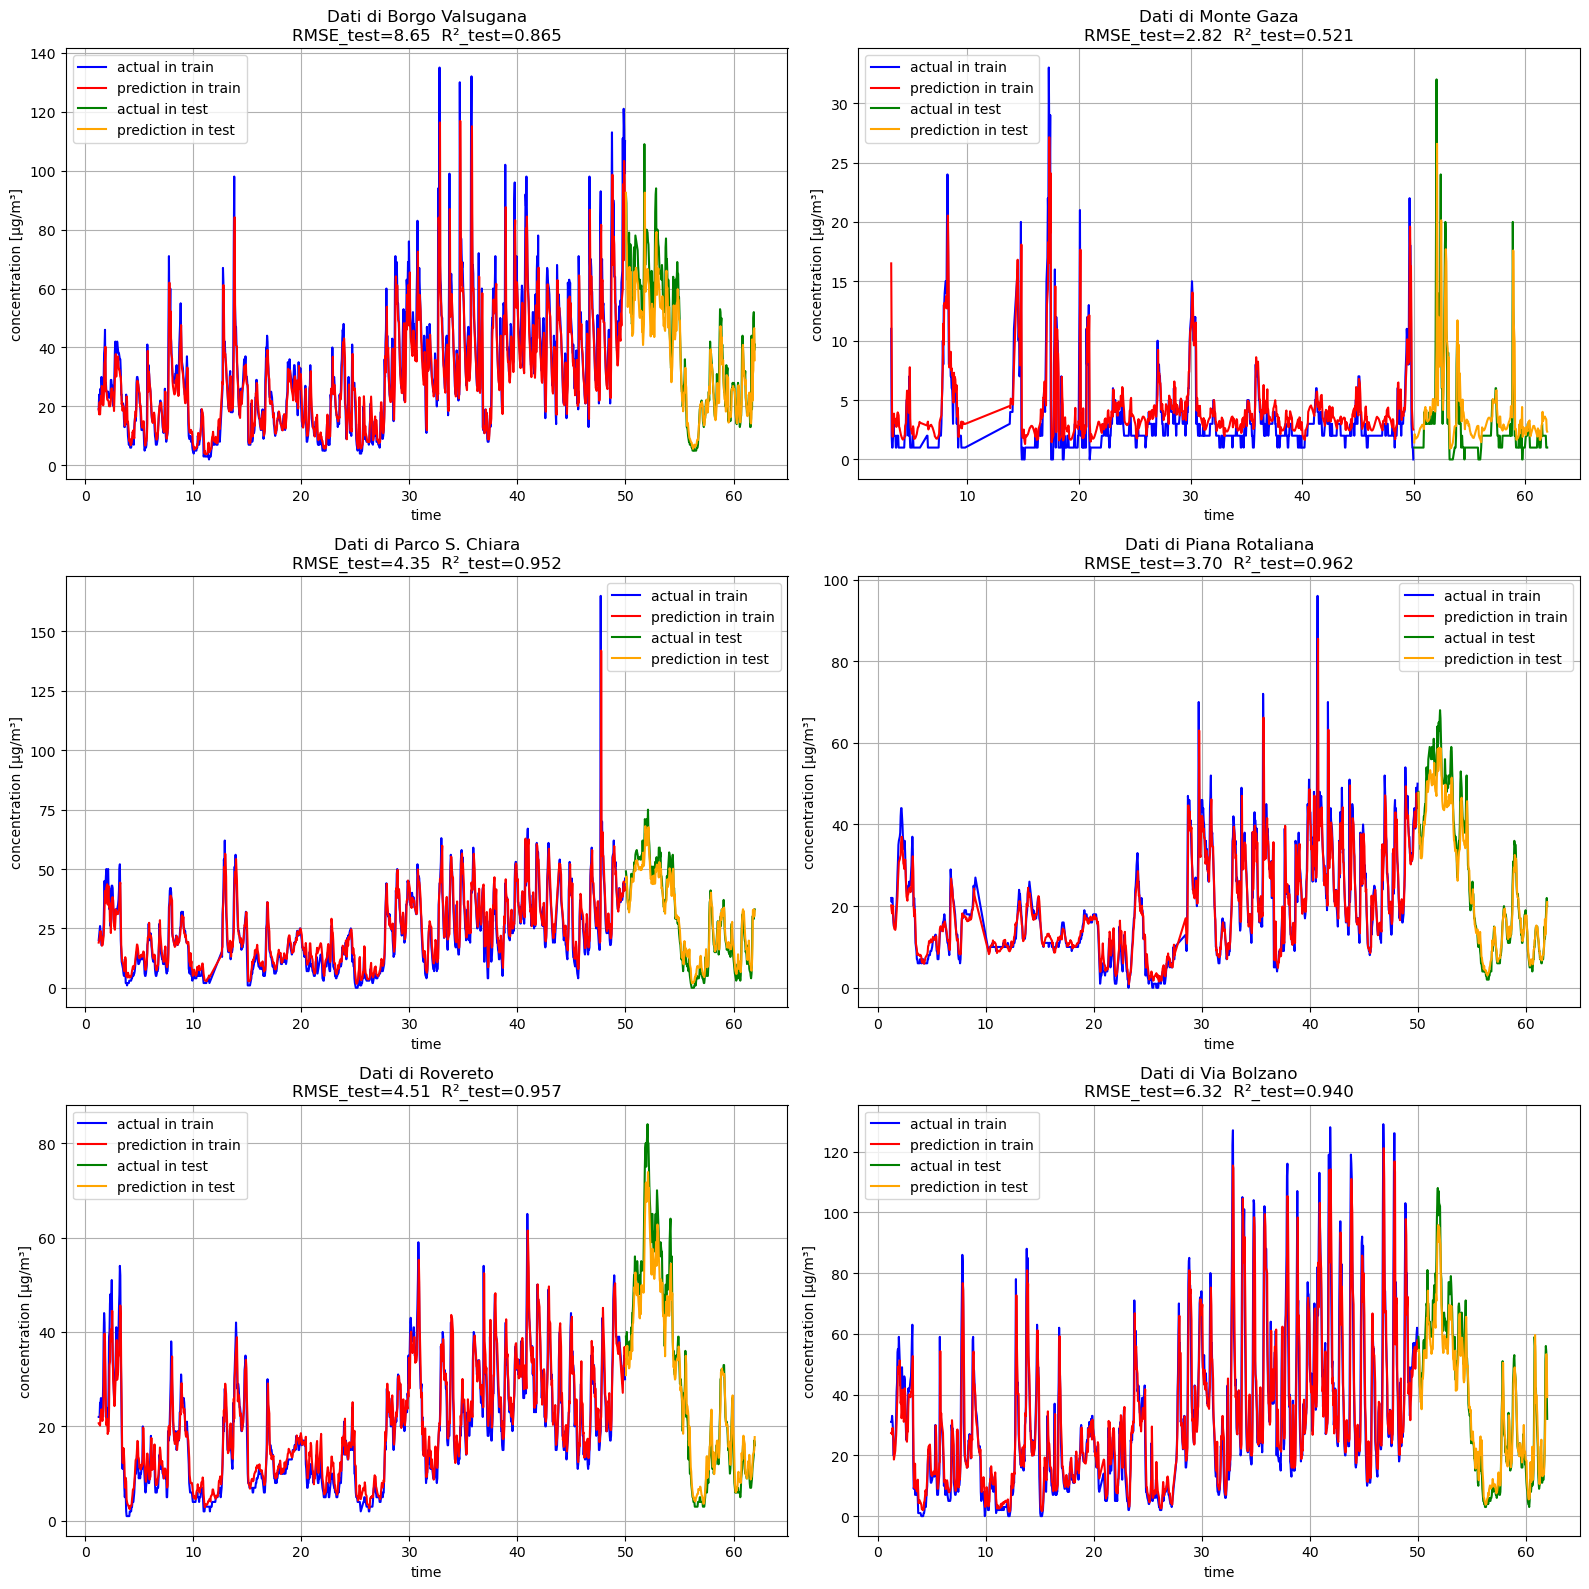

In [15]:
fs.plot_predictions(best_model, hPM10_X_train, hPM10_y_train, hPM10_X_test, hPM10_y_test)

In realtà sembra esserci un miglioramento della predittività su Monte Gaza (seppure con un evidente bias verticale), a discapito di tutte le altre stazioni, che peggiorano.

Giusto per curiosità, proviamo ad escludere Monte Gaza dal dataset e a confrontare nuovamente i risultati per i due modelli. Cerchiamo così di capire se l'elasticnet non sia magari stato mandato fuori strada dalla singola stazione difficile da prevedere.

In [16]:
# cambiamo il dataset droppando le righe e le colonne che non vogliamo
m_hour_PM10_df = hour_PM10_df[hour_PM10_df['station_Monte Gaza'] == 0].copy()
m_hour_PM10_df.drop(columns='station_Monte Gaza', inplace=True)

In [17]:
# reinizializziamo i modelli
non_num_features = [col for col in m_hour_PM10_df.columns if col.startswith('station_')]
num_features = m_hour_PM10_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('one-hot', 'passthrough', non_num_features)
])

# cross validation per time series
tscv = TimeSeriesSplit(n_splits=5)

## linear regression
model_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression(n_jobs = -1))
])

## elasticnet
model_en = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(random_state=seed, max_iter=20000, tol=1e-3))
])

param_grid_en = {
    'regressor__alpha': np.logspace(-2, 2, 50),                     # valori di alpha per il regolarizzatore
    'regressor__l1_ratio': [0.001, 0.1, 0.25, 0.5, 0.75, 1.0],      # rateo l1/l2 -> NB mettiamo 0.001 invece che 0.0, perché con 0.0 dà problemi di convergenza
    'regressor__fit_intercept': [True, False],                      # sceglie se mettere l'intercetta o no
    'regressor__selection': ['cyclic', 'random'],                   # sceglie il modo in aggiornare le features
}

gridsrc_en = GridSearchCV(estimator=model_en,                                       # usiamo la pipeline
                         param_grid=param_grid_en,                                  # cerchiamo gli iperparametri migliori
                         scoring='neg_root_mean_squared_error',                     # metro di ottimizzazione
                         cv=tscv,                                                   # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                         n_jobs=-1,                                                 # usiamo la massima potenza disponibile nella CPU
                         refit=True)                                                # vogliamo poi allenare il modello con i migliori iperparametri

In [18]:
# splittiamo il dataset
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
m_hPM10_X_train, _, m_hPM10_X_test, m_hPM10_y_train, _, m_hPM10_y_test = fs.get_train_valid_test(m_hour_PM10_df, 0.8, 0.0, feature_cols)

In [19]:
# facciamo il fit ai modelli
model_reg.fit(m_hPM10_X_train, m_hPM10_y_train)
gridsrc_en.fit(m_hPM10_X_train, m_hPM10_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__alpha': array([1.0000...00000000e+02]), 'regressor__fit_intercept': [True, False], 'regressor__l1_ratio': [0.001, 0.1, ...], 'regressor__selection': ['cyclic', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose

In [20]:
# scegliamo il miglior modello per il gridsearch e confrontiamo la performance
best_model_en = gridsrc_en.best_estimator_

print('------------------------------------------------')
print('Performance su Train')
print('------------------------------------------------')
print('LinearRegression')
fs.evaluation(model_reg, m_hPM10_X_train, m_hPM10_y_train)
print('------------------------------------------------')
print('ElasticNet')
fs.evaluation(best_model_en, m_hPM10_X_train, m_hPM10_y_train)
print('------------------------------------------------')
print('------------------------------------------------')
print('Performance su Test')
print('------------------------------------------------')
print('LinearRegression')
fs.evaluation(model_reg, m_hPM10_X_test, m_hPM10_y_test)
print('------------------------------------------------')
print('ElasticNet')
fs.evaluation(best_model_en, m_hPM10_X_test, m_hPM10_y_test)

------------------------------------------------
Performance su Train
------------------------------------------------
LinearRegression
Mean Squared Error (MSE):          49.689817578070674
Root Mean Squared Error (RMSE):    7.049100480066281
Mean Absolute Error (MAE):         3.999590728323831
Coefficient of Determination (R2): 0.8580056928066674
------------------------------------------------
ElasticNet
Mean Squared Error (MSE):          51.34822696521145
Root Mean Squared Error (RMSE):    7.165767716386811
Mean Absolute Error (MAE):         3.9875707823835405
Coefficient of Determination (R2): 0.8532665992972177
------------------------------------------------
------------------------------------------------
Performance su Test
------------------------------------------------
LinearRegression
Mean Squared Error (MSE):          29.72417126509714
Root Mean Squared Error (RMSE):    5.451987826939559
Mean Absolute Error (MAE):         3.9976274646653605
Coefficient of Determination (R2

L'elasticnet rimane peggiore della semplice regressione lineare non regolarizzata, seppure la differenza di performance tra i due modelli sembri diminuire. Vista la semplicità del modello ed i risultati migliori, procediamo quindi con LinearRegression per tutti gli studi successivi.

Per affinare la nostra previsione proviamo a fittare un modello polinomiale anziché lineare. Per evitare di avere troppe features, limitiamoci ai polinomi di grado 2 e 3.

#### Modello polinomiale
#### Pipeline

In [21]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in hour_PM10_df.columns if col.startswith('station_')]
num_features = hour_PM10_df.columns.difference(non_num_features + ['target'])

# creiamo una pipeline per la trasformazione
num_transformer_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False))
])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_poly = ColumnTransformer([
    ('num', num_transformer_poly, num_features),
    ('one-hot', 'passthrough', non_num_features)
])

# pipeline
model_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('regressor', LinearRegression())
])

# faccio un gridsearch per ottimizzare sul grado del polinomio
param_grid_poly = {'preprocessor__num__poly__degree': [1, 2, 3]} # ottimizzo tra i primi tre gradi

# cross validation per time series
tscv = TimeSeriesSplit(n_splits=5)

gridsrc_poly = GridSearchCV(
    estimator=model_poly,                                      # usiamo la pipeline
    param_grid=param_grid_poly,                                # cerchiamo gli iperparametri migliori
    scoring='neg_root_mean_squared_error',                     # metro di ottimizzazione
    cv=tscv,                                                   # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
    n_jobs=-1,                                                 # usiamo la massima potenza disponibile nella CPU
    refit=True)                                                # vogliamo poi allenare il modello con i migliori iperparametri

In [22]:
# splittiamo il dataset in train e test e alleniamo il modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
hPM10_X_train, _, hPM10_X_test, hPM10_y_train, _, hPM10_y_test = fs.get_train_valid_test(hour_PM10_df, 0.8, 0.0, feature_cols)

In [23]:
# training
gridsrc_poly.fit(hPM10_X_train, hPM10_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocessor__num__poly__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

#### Che grado ha il miglior modello? E quali sono le sue performance?

In [24]:
print(gridsrc_poly.best_params_)
print('------------------------------------------------')
best_model_poly = gridsrc_poly.best_estimator_
print('Performance su train')
fs.evaluation(best_model_poly, hPM10_X_train, hPM10_y_train)
print('------------------------------------------------')
print('Performance su test')
fs.evaluation(best_model_poly, hPM10_X_test, hPM10_y_test)


{'preprocessor__num__poly__degree': 1}
------------------------------------------------
Performance su train
Mean Squared Error (MSE):          43.00751555572842
Root Mean Squared Error (RMSE):    6.558011555016384
Mean Absolute Error (MAE):         3.5894479465962115
Coefficient of Determination (R2): 0.8795446086798205
------------------------------------------------
Performance su test
Mean Squared Error (MSE):          25.676054431458954
Root Mean Squared Error (RMSE):    5.067154470850376
Mean Absolute Error (MAE):         3.554799790335712
Coefficient of Determination (R2): 0.9533490735044674


Sembra che il modello lineare sia quello che fitta meglio le osservazioni. La performance è infatti uguale a quella del primo studio.

Per il momento ci fermiamo qui con la regressione oraria sui PM10. I risultati che otteniamo a questo livello possono essere considerati sostanzialmente buoni e, seppure la predizione non sia perfetta, immaginiamo che quanto predetto possa essere utile da un'ora all'altra.

Rimandiamo uno studio migliore al random forest nella sua versione di regressore. 

Proviamo quindi a seguire lo stesso procedimento appena riportato per prevedere anche i PM2.5 e l'O3 su base oraria.

### PM2.5

#### Importiamo il dataframe

In [25]:
hour_PM2_5_df = pd.read_csv('../../data/processed/dataset_hour_PM2_5_processed.csv')

hour_PM2_5_df.head()

,station_Borgo Valsugana,station_Parco S. Chiara,station_Rovereto,elevation,day,cos_week_day,sin_week_day,cos_hour,sin_hour,temperature,precipitation,PM2.5_1,PM2.5_2,PM2.5_3,PM2.5_diff_1,PM2.5_diff_2,NO2_1,power_area_50_1,power_area_50_2,target
0,1,0,0,410,1,-0.900969,-0.433884,6.123234e-17,1.000000,10.950,0.0,13.0,11.0,12.0,2.0,1.0,18.0,16.969367,14.669913,13.0
1,1,0,0,410,1,-0.900969,-0.433884,-2.588190e-01,0.965926,11.000,0.0,13.0,13.0,11.0,0.0,2.0,16.0,15.329278,16.969367,16.0
2,1,0,0,410,1,-0.900969,-0.433884,-5.000000e-01,0.866025,10.925,0.0,16.0,13.0,13.0,3.0,3.0,16.0,17.519438,15.329278,11.0
3,1,0,0,410,1,-0.900969,-0.433884,-7.071068e-01,0.707107,10.950,0.0,11.0,16.0,13.0,-5.0,-2.0,15.0,17.446178,17.519438,12.0
4,1,0,0,410,1,-0.900969,-0.433884,-8.660254e-01,0.500000,11.550,0.0,12.0,11.0,16.0,1.0,-4.0,15.0,17.484408,17.446178,14.0


#### Pipeline
Usiamo la stessa pipeline polinomiale vista in precedenza (la pipeline polinomiale tiene conto di un eventuale comportamento polinomiale ed il training non è molto più lungo della semplice regressione di primo grado).

In [26]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in hour_PM2_5_df.columns if col.startswith('station_')]
num_features = hour_PM2_5_df.columns.difference(non_num_features + ['target'])

# creiamo una pipeline per la trasformazione
num_transformer_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False))
])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_poly = ColumnTransformer([
    ('num', num_transformer_poly, num_features),
    ('one-hot', 'passthrough', non_num_features)
])

# pipeline
model_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('regressor', LinearRegression())
])

# faccio un gridsearch per ottimizzare sul grado del polinomio
param_grid_poly = {'preprocessor__num__poly__degree': [1, 2, 3]} # ottimizziamo tra i primi tre gradi

# cross validation per time series
tscv = TimeSeriesSplit(n_splits=5)

gridsrc_poly = GridSearchCV(
    estimator=model_poly,                                      # usiamo la pipeline
    param_grid=param_grid_poly,                                # cerchiamo gli iperparametri migliori
    scoring='neg_root_mean_squared_error',                     # metro di ottimizzazione
    cv=tscv,                                                   # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
    n_jobs=-1,                                                 # usiamo la massima potenza disponibile nella CPU
    refit=True)                                                # vogliamo poi allenare il modello con i migliori iperparametri

#### Train, Test split + fit

In [27]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
hPM2_5_X_train, hPM2_5_X_valid, hPM2_5_X_test, hPM2_5_y_train, hPM2_5_y_valid, hPM2_5_y_test = fs.get_train_valid_test(hour_PM2_5_df, 0.8, 0.0, feature_cols)

In [28]:
gridsrc_poly.fit(hPM2_5_X_train, hPM2_5_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocessor__num__poly__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

#### Performance modello

In [29]:
print(gridsrc_poly.best_params_)
print('------------------------------------------------')
best_model_poly = gridsrc_poly.best_estimator_
print('Performance su train')
fs.evaluation(best_model_poly, hPM2_5_X_train, hPM2_5_y_train)
print('------------------------------------------------')
print('Performance su test')
fs.evaluation(best_model_poly, hPM2_5_X_test, hPM2_5_y_test)

{'preprocessor__num__poly__degree': 1}
------------------------------------------------
Performance su train
Mean Squared Error (MSE):          26.0692617912828
Root Mean Squared Error (RMSE):    5.105806673904016
Mean Absolute Error (MAE):         2.992068810697448
Coefficient of Determination (R2): 0.8266090666261423
------------------------------------------------
Performance su test
Mean Squared Error (MSE):          23.28174084864444
Root Mean Squared Error (RMSE):    4.825115630598343
Mean Absolute Error (MAE):         3.6344510982675446
Coefficient of Determination (R2): 0.9232684265961171


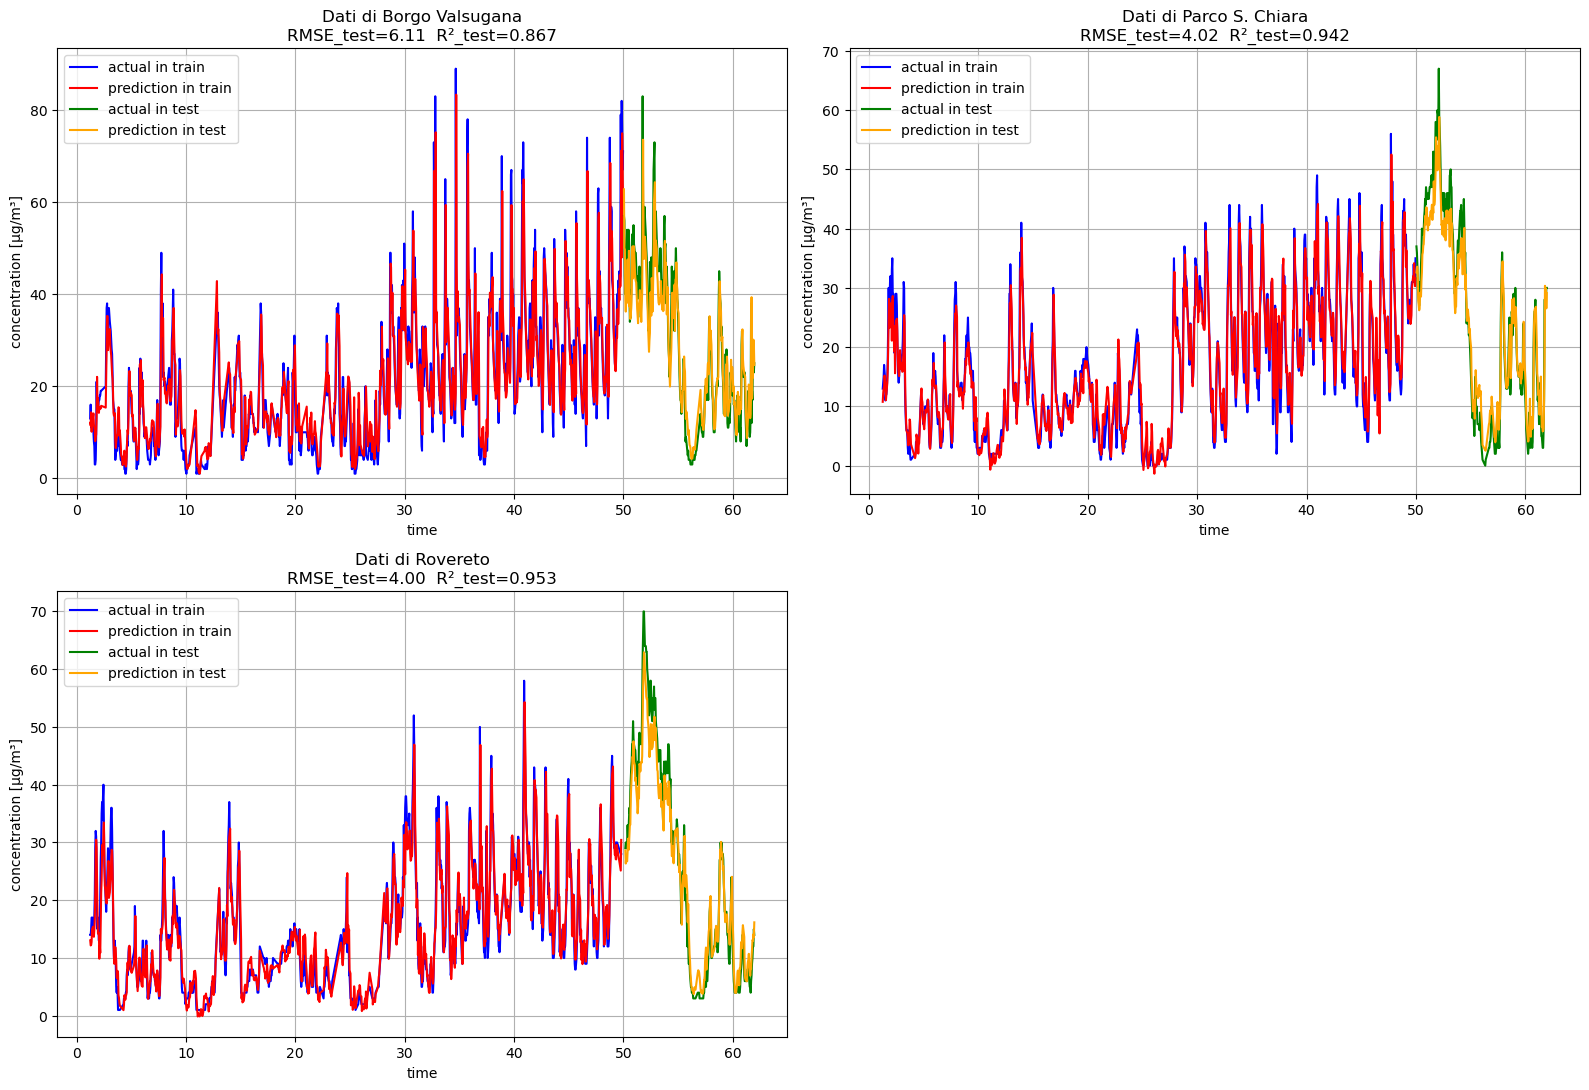

In [30]:
fs.plot_predictions(best_model_poly, hPM2_5_X_train, hPM2_5_y_train, hPM2_5_X_test, hPM2_5_y_test)

Come per i PM10 il modello sembra seguire molto bene l'andamento dei dati reali, con una capacità di generalizzazione molto buona, come si vede da mean square error molto piccolo sul test (addirittura minore che sul train).

Sia per l'R^2 che per il MSE la performance sembra peggiore rispetto ai PM10.

### O3

#### Importiamo il dataframe

In [31]:
hour_O3_df = pd.read_csv('../../data/processed/dataset_hour_O3_processed.csv')

# droppiamo la feature Riva del Garda, che tanto non ha dati associati
hour_O3_df.drop(columns='station_Riva del Garda', inplace=True)

hour_O3_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Rovereto,elevation,day,cos_week_day,sin_week_day,cos_hour,...,O3_1,O3_2,O3_3,O3_diff_1,O3_diff_2,PM10_1,NO2_1,power_area_50_1,power_area_50_2,target
0,1,0,0,0,0,410,1,-0.900969,-0.433884,6.123234e-17,...,2.0,2.0,2.0,0.0,0.0,21.0,18.0,16.969367,14.669913,2.0
1,1,0,0,0,0,410,1,-0.900969,-0.433884,-2.588190e-01,...,2.0,2.0,2.0,0.0,0.0,19.0,16.0,15.329278,16.969367,2.0
2,1,0,0,0,0,410,1,-0.900969,-0.433884,-5.000000e-01,...,2.0,2.0,2.0,0.0,0.0,24.0,16.0,17.519438,15.329278,2.0
3,1,0,0,0,0,410,1,-0.900969,-0.433884,-7.071068e-01,...,2.0,2.0,2.0,0.0,0.0,19.0,15.0,17.446178,17.519438,3.0
4,1,0,0,0,0,410,1,-0.900969,-0.433884,-8.660254e-01,...,3.0,2.0,2.0,1.0,1.0,22.0,15.0,17.484408,17.446178,5.0


#### Pipeline
Usiamo la stessa pipeline polinomiale vista in precedenza (la pipeline polinomiale tiene conto di un eventuale comportamento polinomiale ed il training non è molto più lungo della semplice regressione di primo grado).

In [32]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in hour_O3_df.columns if col.startswith('station_')]
num_features = hour_O3_df.columns.difference(non_num_features + ['target'])

# creiamo una pipeline per la trasformazione
num_transformer_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False))
])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_poly = ColumnTransformer([
    ('num', num_transformer_poly, num_features),
    ('one-hot', 'passthrough', non_num_features)
])

# pipeline
model_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('regressor', LinearRegression())
])

# faccio un gridsearch per ottimizzare sul grado del polinomio
param_grid_poly = {'preprocessor__num__poly__degree': [1, 2, 3]} # ottimizziamo tra i primi tre gradi

# cross validation per time series
tscv = TimeSeriesSplit(n_splits=5)

gridsrc_poly = GridSearchCV(
    estimator=model_poly,                                      # usiamo la pipeline
    param_grid=param_grid_poly,                                # cerchiamo gli iperparametri migliori
    scoring='neg_root_mean_squared_error',                     # metro di ottimizzazione
    cv=tscv,                                                   # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
    n_jobs=-1,                                                 # usiamo la massima potenza disponibile nella CPU
    refit=True)                                                # vogliamo poi allenare il modello con i migliori iperparametri

#### Train, Test split + fit

In [33]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
hO3_X_train, hO3_X_valid, hO3_X_test, hO3_y_train, hO3_y_valid, hO3_y_test = fs.get_train_valid_test(hour_O3_df, 0.8, 0.0, feature_cols)

In [34]:
gridsrc_poly.fit(hO3_X_train, hO3_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocessor__num__poly__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

#### Performance modello

In [35]:
print(gridsrc_poly.best_params_)
print('------------------------------------------------')
best_model_poly = gridsrc_poly.best_estimator_
print('Performance su Train')
fs.evaluation(best_model_poly, hO3_X_train, hO3_y_train)
print('------------------------------------------------')
print('Performance su Test')
fs.evaluation(best_model_poly, hO3_X_test, hO3_y_test)

{'preprocessor__num__poly__degree': 1}
------------------------------------------------
Performance su Train
Mean Squared Error (MSE):          23.25406994048632
Root Mean Squared Error (RMSE):    4.8222473951972145
Mean Absolute Error (MAE):         2.8983616226479345
Coefficient of Determination (R2): 0.9722967348687024
------------------------------------------------
Performance su Test
Mean Squared Error (MSE):          14.500341157969084
Root Mean Squared Error (RMSE):    3.807931348904426
Mean Absolute Error (MAE):         2.228784426832779
Coefficient of Determination (R2): 0.9832499570510038


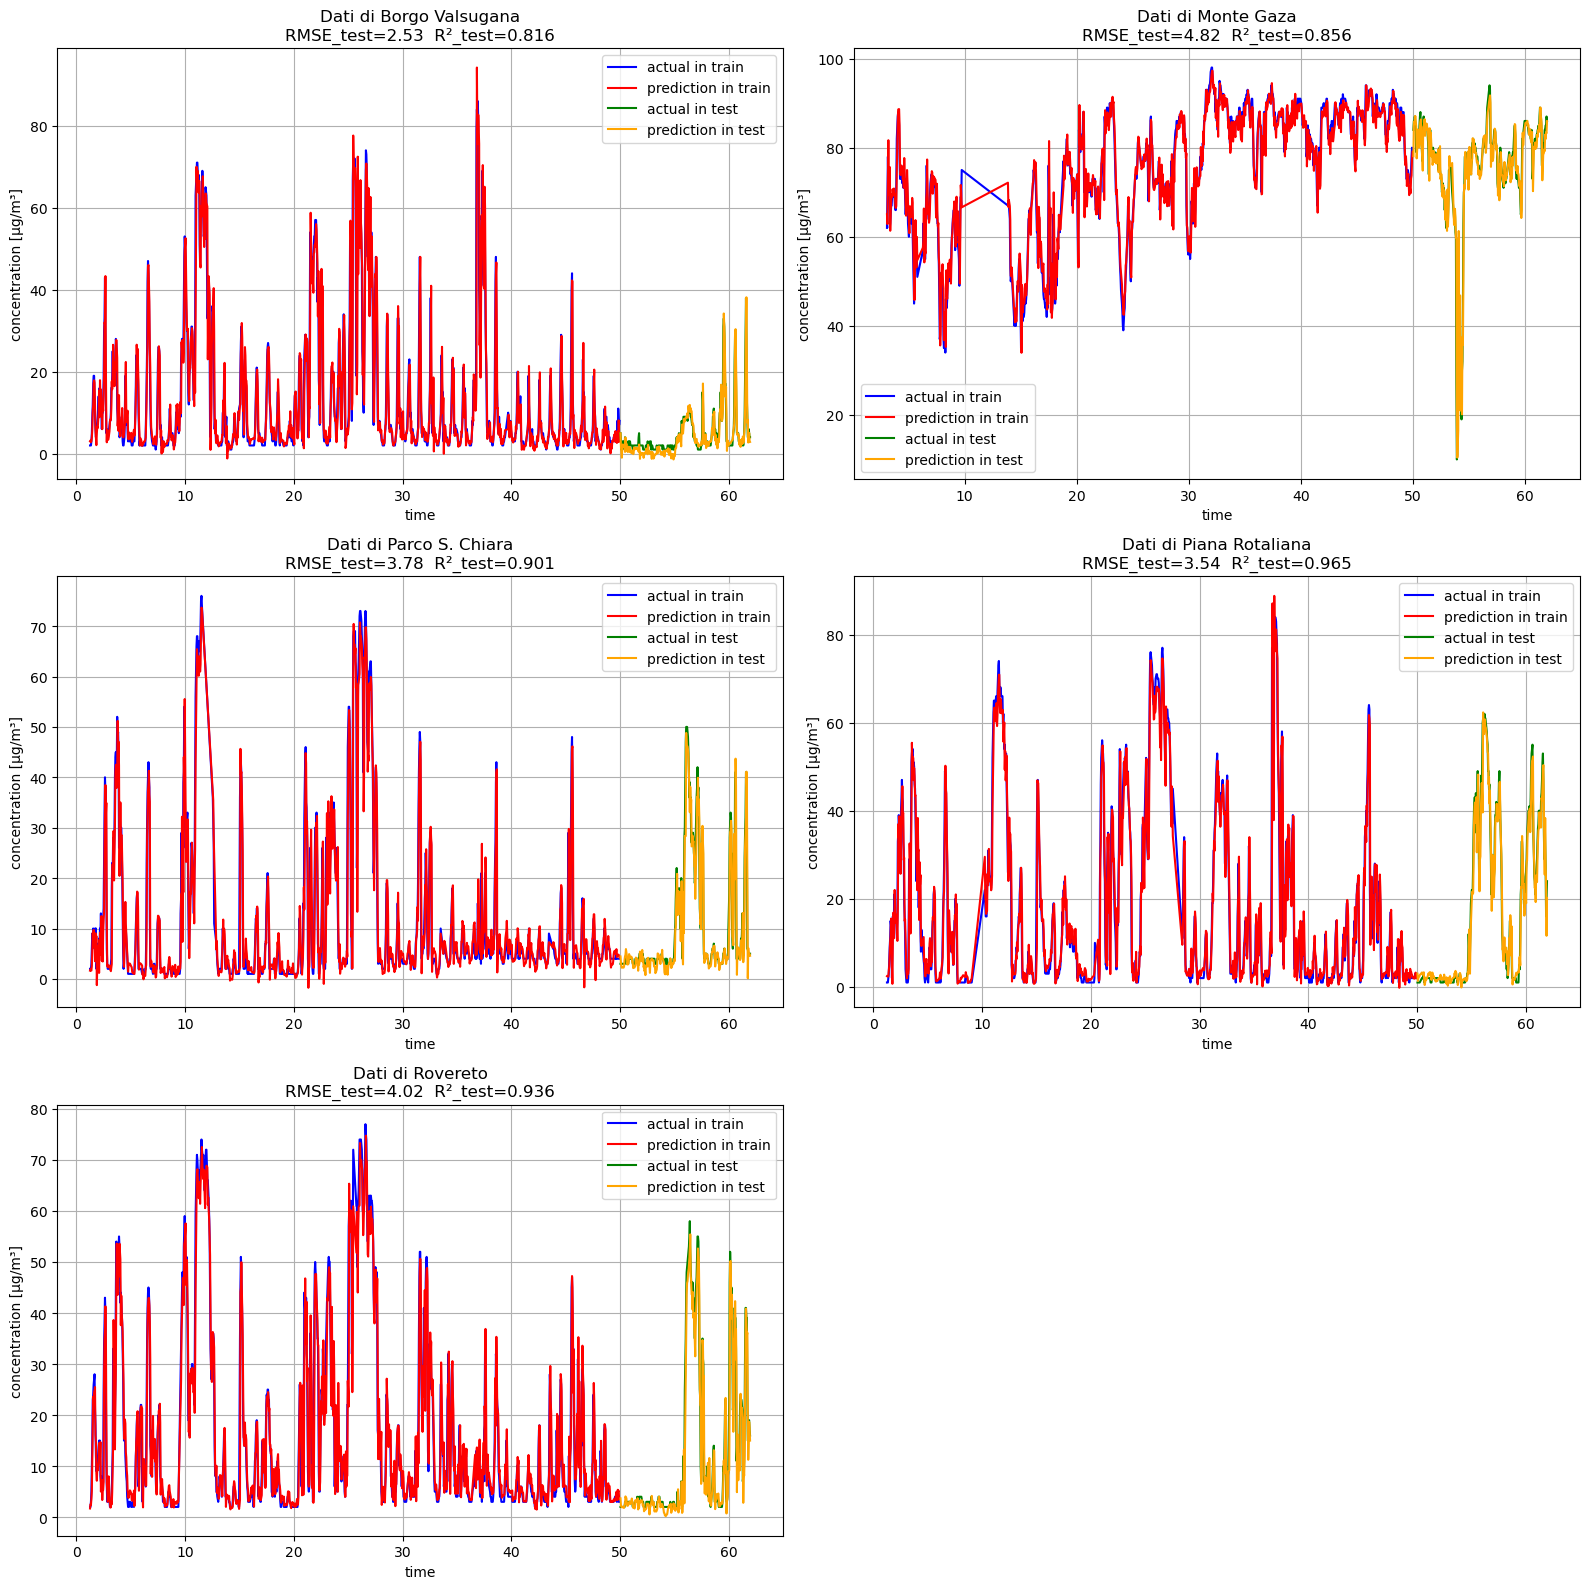

In [36]:
fs.plot_predictions(best_model_poly, hO3_X_train, hO3_y_train, hO3_X_test, hO3_y_test)

La performance sulla previsione dell'andamento che osserviamo è molto simile a quella vista per i precedenti due inquinanti. Senza dilungarsi troppo sul commento, notiamo in particolare come il modello mostri i parametri R^2 e MSE migliori fino ad ora.

## Studio giornaliero

### PM10

#### Importiamo il dataframe

In [37]:
# Importiamo il dataframe costruito separatamente
daily_PM10_df = pd.read_csv('../../data/processed/dataset_day_PM10_processed.csv')

# droppiamo la feature Riva del Garda, che tanto non ha dati associati
daily_PM10_df.drop(columns='station_Riva del Garda', inplace=True)

daily_PM10_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,sin_week_day,temperature,precipitation,PM10_1,PM10_2,PM10_diff_1,NO2_1,power_area_50_1,target
0,1,0,0,0,0,0,410,3,0.623490,-0.781831,11.231522,0.013043,28.869565,25.739130,3.130435,21.086957,18.197335,23.652174
1,1,0,0,0,0,0,410,4,1.000000,0.000000,10.796739,0.126087,23.652174,28.869565,-5.217391,18.826087,17.478475,14.739130
2,1,0,0,0,0,0,410,5,0.623490,0.781831,7.609783,0.028261,14.739130,23.652174,-8.913043,26.739130,37.200400,17.000000
3,1,0,0,0,0,0,410,6,-0.222521,0.974928,9.641304,0.000000,17.000000,14.739130,2.260870,25.913043,37.421266,14.739130
4,1,0,0,0,0,0,410,7,-0.900969,0.433884,9.980435,0.000000,14.739130,17.000000,-2.260870,26.956522,35.957377,26.086957


#### Pipeline
In questo caso partiamo direttamente dal modello polinomiale in modo da vagliare tutte le possibilità

In [38]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in daily_PM10_df.columns if col.startswith('station_')]
num_features = daily_PM10_df.columns.difference(non_num_features + ['target'])

# creiamo una pipeline per la trasformazione
num_transformer_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False))
])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_poly = ColumnTransformer([
    ('num', num_transformer_poly, num_features),
    ('one-hot', 'passthrough', non_num_features)
])

# pipeline
model_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('regressor', LinearRegression())
])

# faccio un gridsearch per ottimizzare sul grado del polinomio
param_grid_poly = {'preprocessor__num__poly__degree': [1, 2, 3]} # ottimizzo tra i primi tre gradi

# cross validation per time series
tscv = TimeSeriesSplit(n_splits=5)

gridsrc_poly = GridSearchCV(
    estimator=model_poly,                                      # usiamo la pipeline
    param_grid=param_grid_poly,                                # cerchiamo gli iperparametri migliori
    scoring='neg_root_mean_squared_error',                     # metro di ottimizzazione
    cv=tscv,                                                   # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
    n_jobs=-1,                                                 # usiamo la massima potenza disponibile nella CPU
    refit=True)                                                # vogliamo poi allenare il modello con i migliori iperparametri

#### Train, Test split + fit

In [39]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
day_PM10_X_train, _, day_PM10_X_test, day_PM10_y_train, _, day_PM10_y_test = fs.get_train_valid_test(daily_PM10_df, 0.8, 0.0, feature_cols)

In [40]:
# training
gridsrc_poly.fit(day_PM10_X_train, day_PM10_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocessor__num__poly__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

#### Performance modello

In [41]:
print(gridsrc_poly.best_params_)
print('------------------------------------------------')
best_model_poly = gridsrc_poly.best_estimator_
print('Performance su train')
fs.evaluation(best_model_poly, day_PM10_X_train, day_PM10_y_train)
print('------------------------------------------------')
print('Performance su test')
fs.evaluation(best_model_poly, day_PM10_X_test, day_PM10_y_test)

{'preprocessor__num__poly__degree': 1}
------------------------------------------------
Performance su train
Mean Squared Error (MSE):          42.59536133488952
Root Mean Squared Error (RMSE):    6.52651218759986
Mean Absolute Error (MAE):         4.990970549381883
Coefficient of Determination (R2): 0.8139574979088822
------------------------------------------------
Performance su test
Mean Squared Error (MSE):          188.64177826813562
Root Mean Squared Error (RMSE):    13.734692507229116
Mean Absolute Error (MAE):         10.745069135374397
Coefficient of Determination (R2): 0.5967168781553853


Vediamo che il modello funziona decisamente peggio rispetto a prima sotto tutti i punti di vista. Questo è potenzialmente legato ad un problema di overfitting ma riteniamo che, in realtà, sia dovuto ad altre caratteristiche del nostro dataset. La ridotta quantità di dati e la marcata differenza nella distribuzione dei dati tra train e test sono entrambi fattori che determinano quasi inevitabilmente una perdita di accuratezza per il nostro modello.

Proviamo a capire graficamente come stia lavorando il nostro modello.

#### Grafico previsioni
In questo caso, avendo molti meno dati, scegliamo di rappresentare i singoli punti in modo da poter confrontare accuratamente dati e previsioni.

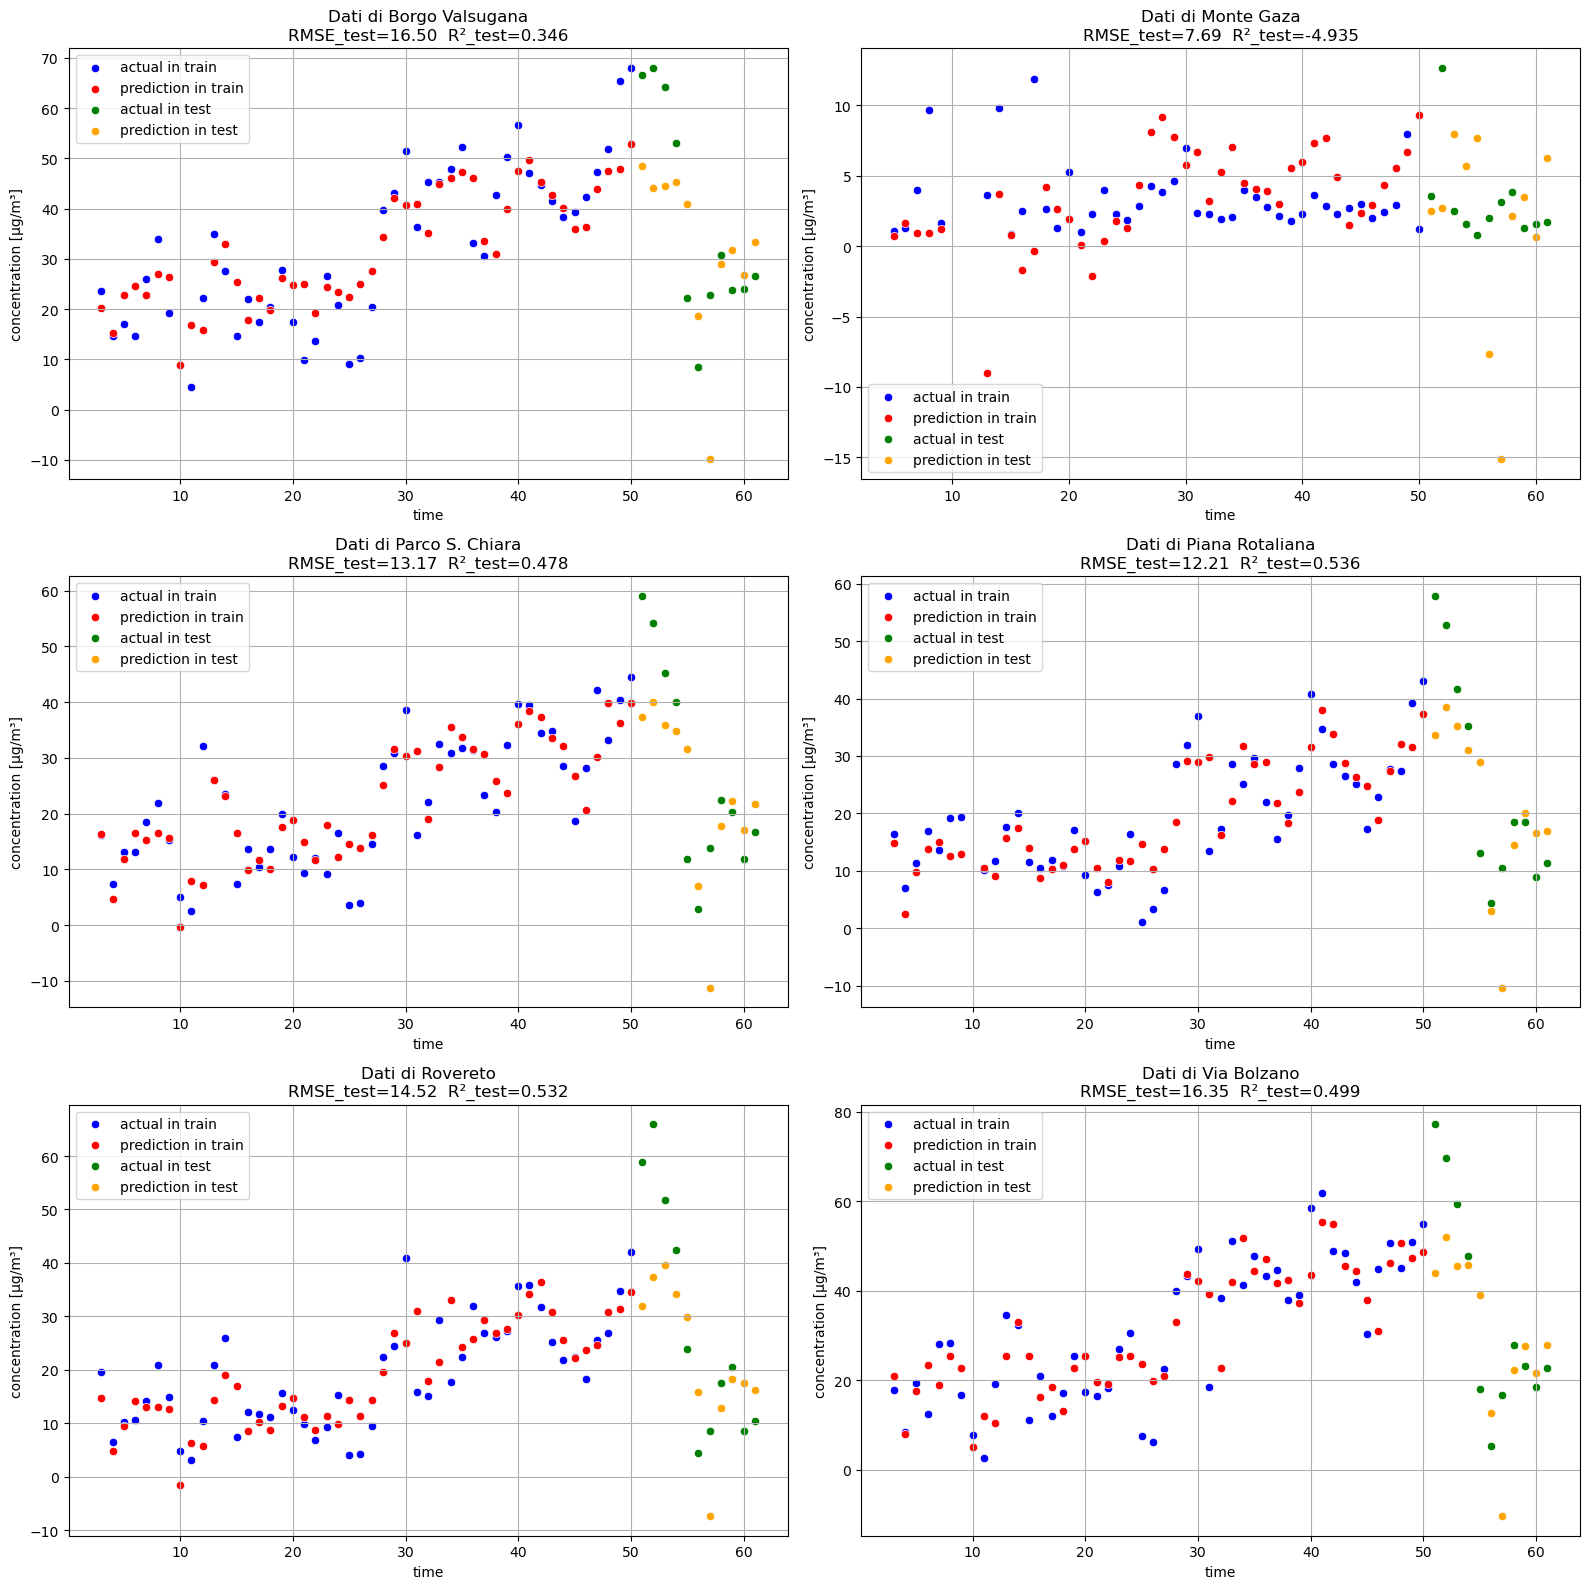

In [42]:
fs.plot_prediction_points(best_model_poly, day_PM10_X_train, day_PM10_y_train, day_PM10_X_test, day_PM10_y_test)

Vediamo che il modello ha prestazioni decenti nell'insieme di allenamento, almeno per la maggior parte delle stazioni, ma in test performa decisamente peggio, soprattutto in corrispondenza al grande picco di inquinanti dovuto al periodo natalizio. Come spiegato sopra, il modello si interfaccia con dati di questa magnitudo solo in test e quindi non ha basi per poterli prevedere accuratamente. Questo problema non è risolvibile senza incrementare il numero di dati e, perciò, per il momento ci accontentiamo dei risultati in vista di un successivo studio tramite random forest.

Ultimo problema che proviamo a risolvere è quello della presenza di risultati negativi, che sono non fisici e che pertanto vorremmo rendere impossibili al modello da prevedere. Per fare ciò proviamo a convertire i dati di target in una scala logaritmica prima di fare il fit.

#### Logaritmo del target

In [43]:
# faccio il logaritmo del target
day_PM10_y_train_log = np.log1p(day_PM10_y_train)
day_PM10_y_test_log = np.log1p(day_PM10_y_test)

# training
gridsrc_poly.fit(day_PM10_X_train, day_PM10_y_train_log)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocessor__num__poly__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

Confrontiamo solo qualitativamente i risultati di questo nuovo allenamento, confrontando i risultati precedenti con i risultati nuovi

{'preprocessor__num__poly__degree': 1}
------------------------------------------------


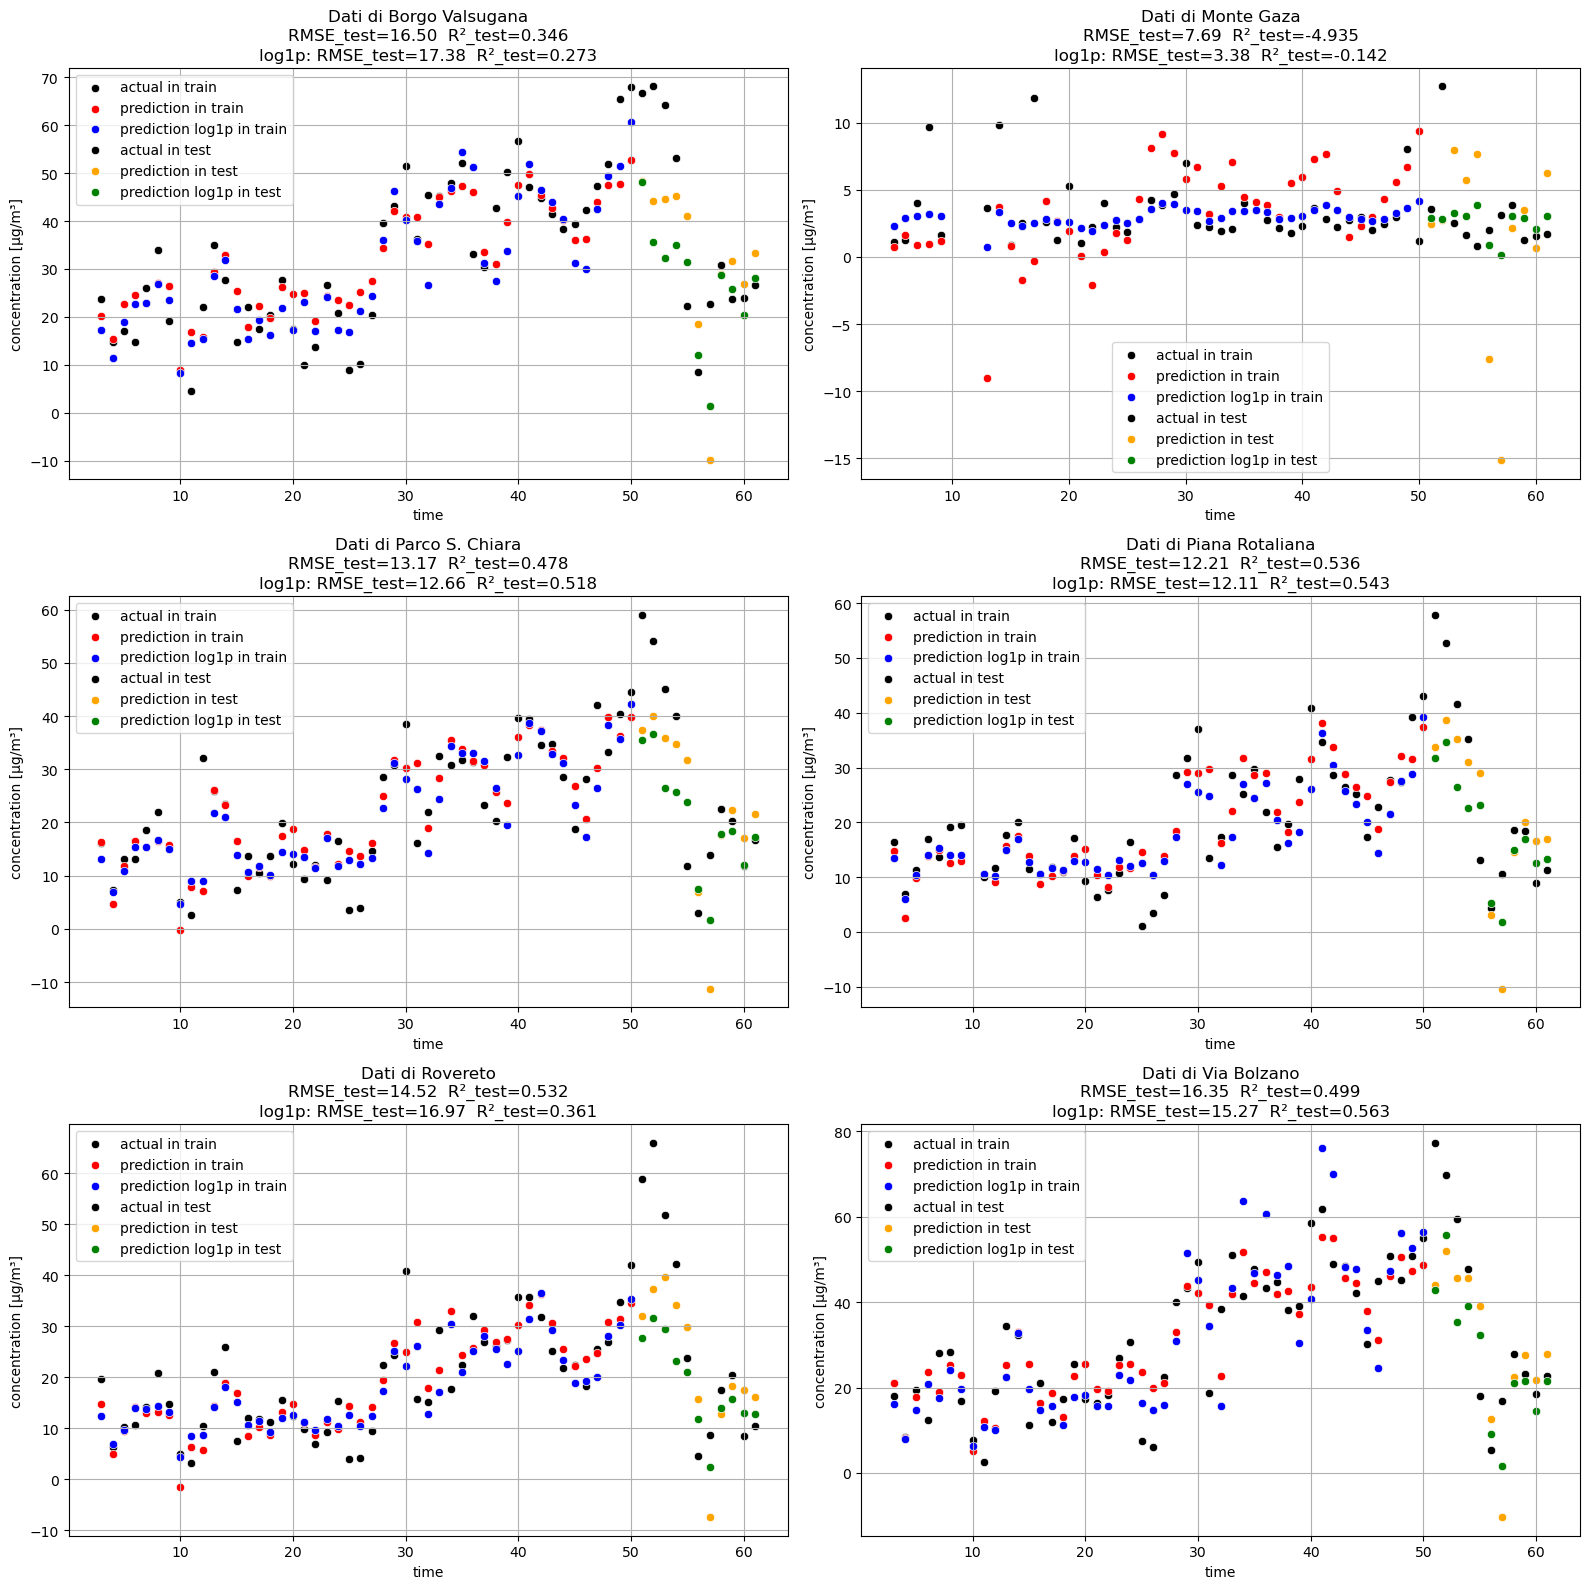

In [44]:
print(gridsrc_poly.best_params_)
print('------------------------------------------------')
best_model_log1p = gridsrc_poly.best_estimator_
fs.plot_comparison_points(best_model_poly, best_model_log1p, day_PM10_X_train, day_PM10_y_train, day_PM10_X_test, day_PM10_y_test)

L'introduzione del target come logaritmo porta sia a miglioramenti che a peggioramenti locali della performance. Probabilmente la gran parte del miglioramento che osserviamo viene proprio dall'assenza di predizioni negative, con gli errori che vengono ridotti notevolmente come conseguenza.\
Il picco a natale sembra invece predetto meglio dal modello lineare standard.

In generale, proprio per l'assenza di predizioni negative, e dunque non fisiche, tenderemo a preferire questo secondo modello rispetto al primo.

Passiamo quindi rapidamente alla regressione per PM2.5 e ozono, in cui i procedimenti sono quasi identici a quelli appena riportati. Per tale motivo riduciamo al minimo i commenti.

### PM2.5

#### Importiamo il dataframe

In [45]:
# Importiamo il dataframe costruito separatamente
daily_PM2_5_df = pd.read_csv('../../data/processed/dataset_day_PM2_5_processed.csv')

daily_PM2_5_df.head()

,station_Borgo Valsugana,station_Parco S. Chiara,station_Rovereto,elevation,day,cos_week_day,sin_week_day,temperature,precipitation,PM2.5_1,PM2.5_2,PM2.5_diff_1,NO2_1,power_area_50_1,target
0,1,0,0,410,3,0.623490,-0.781831,11.231522,0.013043,24.764706,11.391304,13.373402,21.086957,18.197335,15.739130
1,1,0,0,410,4,1.000000,0.000000,10.796739,0.126087,15.739130,24.764706,-9.025575,18.826087,17.478475,8.347826
2,1,0,0,410,5,0.623490,0.781831,7.609783,0.028261,8.347826,15.739130,-7.391304,26.739130,37.200400,11.565217
3,1,0,0,410,6,-0.222521,0.974928,9.641304,0.000000,11.565217,8.347826,3.217391,25.913043,37.421266,8.260870
4,1,0,0,410,7,-0.900969,0.433884,9.980435,0.000000,8.260870,11.565217,-3.304348,26.956522,35.957377,16.478261


#### Pipeline

In [46]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in daily_PM2_5_df.columns if col.startswith('station_')]
num_features = daily_PM2_5_df.columns.difference(non_num_features + ['target'])

# creiamo una pipeline per la trasformazione
num_transformer_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False))
])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_poly = ColumnTransformer([
    ('num', num_transformer_poly, num_features),
    ('one-hot', 'passthrough', non_num_features)
])

# pipeline
model_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('regressor', LinearRegression())
])

# faccio un gridsearch per ottimizzare sul grado del polinomio
param_grid_poly = {'preprocessor__num__poly__degree': [1, 2, 3]} # ottimizzo tra i primi tre gradi

# cross validation per time series
tscv = TimeSeriesSplit(n_splits=5)

gridsrc_poly = GridSearchCV(
    estimator=model_poly,                                      # usiamo la pipeline
    param_grid=param_grid_poly,                                # cerchiamo gli iperparametri migliori
    scoring='neg_root_mean_squared_error',                     # metro di ottimizzazione
    cv=tscv,                                                   # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
    n_jobs=-1,                                                 # usiamo la massima potenza disponibile nella CPU
    refit=True)                                                # vogliamo poi allenare il modello con i migliori iperparametri

#### Train, Test split + fit

In [47]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
day_PM2_5_X_train, _, day_PM2_5_X_test, day_PM2_5_y_train, _, day_PM2_5_y_test = fs.get_train_valid_test(daily_PM2_5_df, 0.8, 0.0, feature_cols)

In [48]:
# faccio il logaritmo del target
day_PM2_5_y_train_log = np.log1p(day_PM2_5_y_train)
day_PM2_5_y_test_log = np.log1p(day_PM2_5_y_test)

# training
gridsrc_poly.fit(day_PM2_5_X_train, day_PM2_5_y_train)
best_model_poly = gridsrc_poly.best_estimator_
gridsrc_poly.fit(day_PM2_5_X_train, day_PM2_5_y_train_log)
best_model_poly_log1p = gridsrc_poly.best_estimator_

#### Performance modello

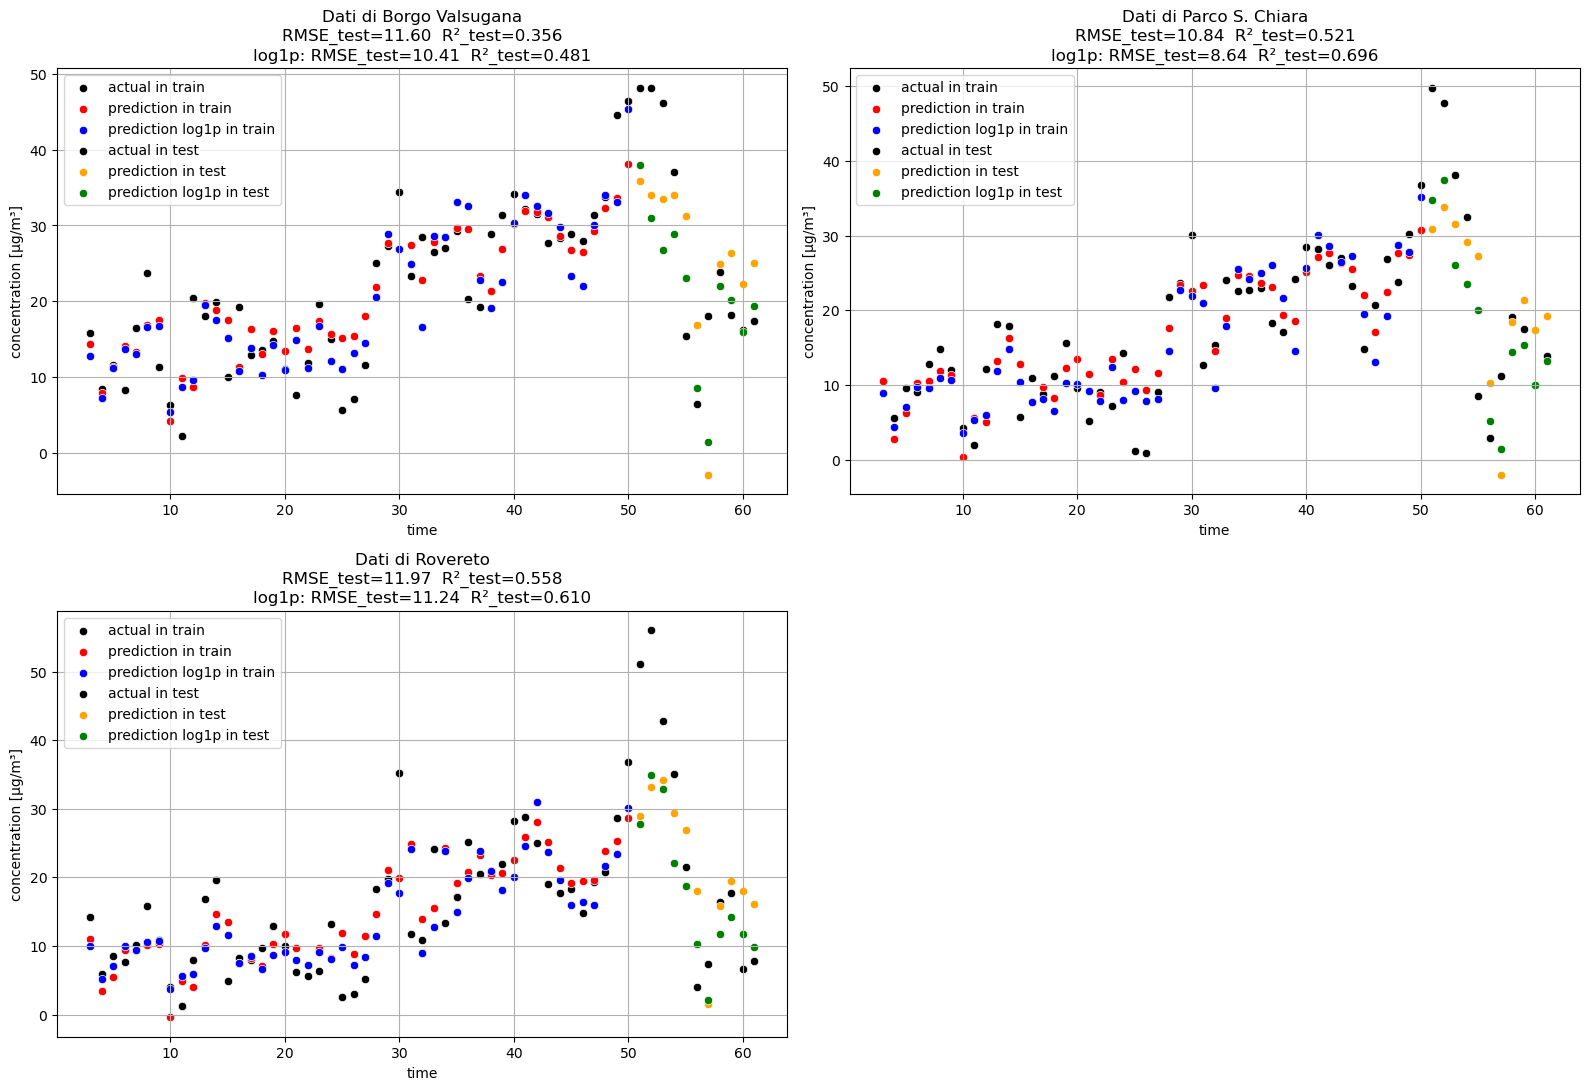

In [49]:
fs.plot_comparison_points(best_model_poly, best_model_poly_log1p, day_PM2_5_X_train, day_PM2_5_y_train, day_PM2_5_X_test, day_PM2_5_y_test)

### O3

#### Importiamo il dataframe

In [50]:
# Importiamo il dataframe costruito separatamente
daily_O3_df = pd.read_csv('../../data/processed/dataset_day_O3_processed.csv')

daily_O3_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,elevation,day,cos_week_day,sin_week_day,temperature,precipitation,O3_1,O3_2,O3_diff_1,PM10_1,NO2_1,power_area_50_1,target
0,1,0,0,0,0,0,410,3,0.623490,-0.781831,11.231522,0.013043,14.086957,7.043478,7.043478,28.869565,21.086957,18.197335,15.608696
1,1,0,0,0,0,0,410,4,1.000000,0.000000,10.796739,0.126087,15.608696,14.086957,1.521739,23.652174,18.826087,17.478475,6.086957
2,1,0,0,0,0,0,410,5,0.623490,0.781831,7.609783,0.028261,6.086957,15.608696,-9.521739,14.739130,26.739130,37.200400,8.478261
3,1,0,0,0,0,0,410,6,-0.222521,0.974928,9.641304,0.000000,8.478261,6.086957,2.391304,17.000000,25.913043,37.421266,14.608696
4,1,0,0,0,0,0,410,7,-0.900969,0.433884,9.980435,0.000000,14.608696,8.478261,6.130435,14.739130,26.956522,35.957377,7.869565


#### Pipeline

In [51]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in daily_O3_df.columns if col.startswith('station_')]
num_features = daily_O3_df.columns.difference(non_num_features + ['target'])

# creiamo una pipeline per la trasformazione
num_transformer_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False))
])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_poly = ColumnTransformer([
    ('num', num_transformer_poly, num_features),
    ('one-hot', 'passthrough', non_num_features)
])

# pipeline
model_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('regressor', LinearRegression())
])

# faccio un gridsearch per ottimizzare sul grado del polinomio
param_grid_poly = {'preprocessor__num__poly__degree': [1, 2, 3]} # ottimizzo tra i primi tre gradi

# cross validation per time series
tscv = TimeSeriesSplit(n_splits=5)

gridsrc_poly = GridSearchCV(
    estimator=model_poly,                                      # usiamo la pipeline
    param_grid=param_grid_poly,                                # cerchiamo gli iperparametri migliori
    scoring='neg_root_mean_squared_error',                     # metro di ottimizzazione
    cv=tscv,                                                   # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
    n_jobs=-1,                                                 # usiamo la massima potenza disponibile nella CPU
    refit=True)                                                # vogliamo poi allenare il modello con i migliori iperparametri

#### Train, Test split + fit

In [52]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
day_O3_X_train, _, day_O3_X_test, day_O3_y_train, _, day_O3_y_test = fs.get_train_valid_test(daily_O3_df, 0.8, 0.0, feature_cols)

In [53]:
# faccio il logaritmo del target
day_O3_y_train_log = np.log1p(day_O3_y_train)
day_O3_y_test_log = np.log1p(day_O3_y_test)

# training
gridsrc_poly.fit(day_O3_X_train, day_O3_y_train)
best_model_poly = gridsrc_poly.best_estimator_
gridsrc_poly.fit(day_O3_X_train, day_O3_y_train_log)
best_model_poly_log1p = gridsrc_poly.best_estimator_

#### Performance modello

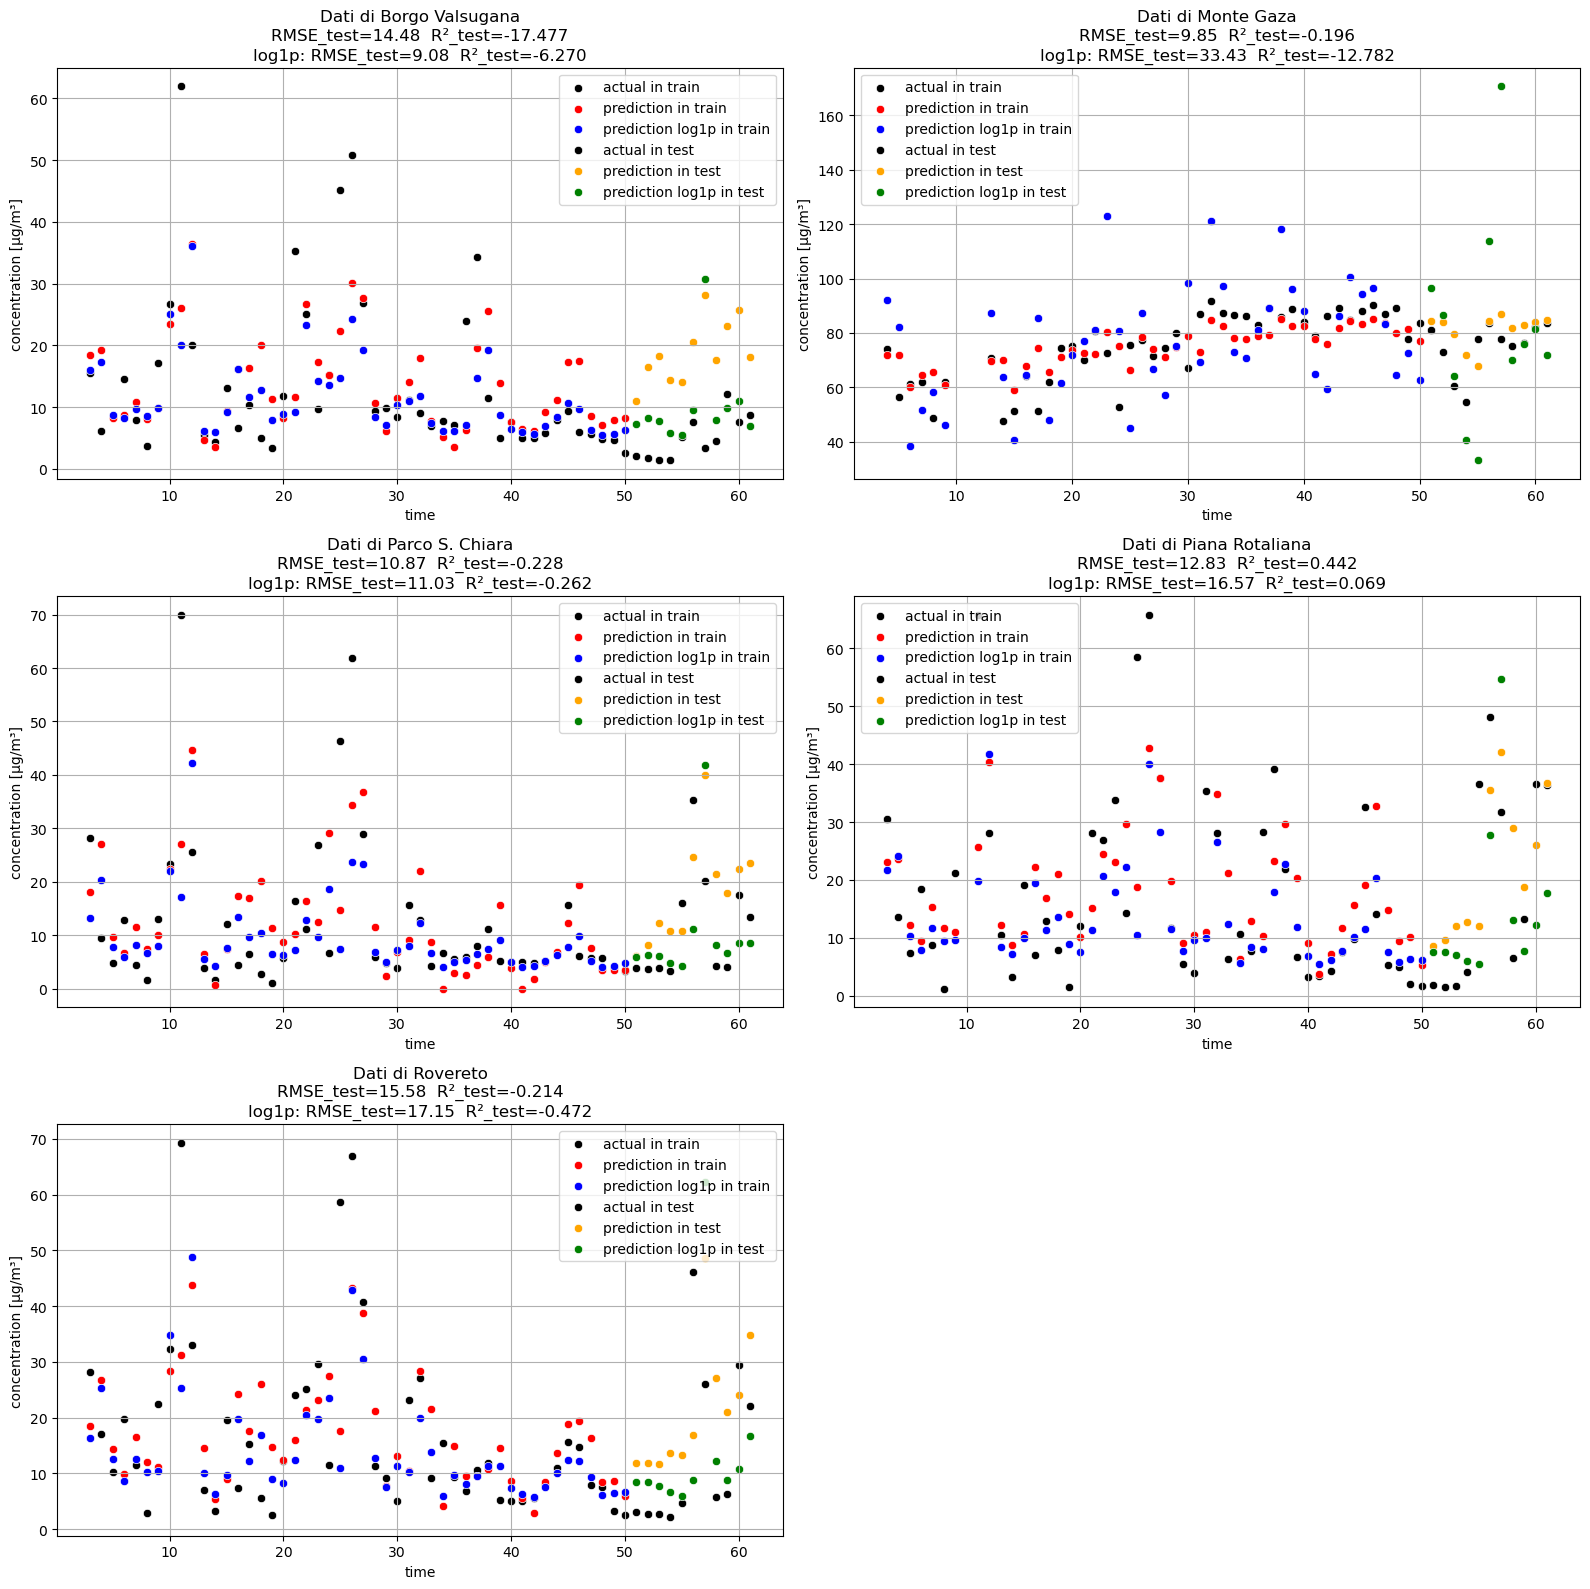

In [54]:
fs.plot_comparison_points(best_model_poly, best_model_poly_log1p, day_O3_X_train, day_O3_y_train, day_O3_X_test, day_O3_y_test)

La regressione tramite LinearRegression è così conclusa. Passiamo ora al notebook 08 dove verrà seguito più o meno lo stesso procedimento per fittare i dati tramite RandomForestRegressor.